### 1: Setup e Bibliotecas

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Configuração visual profissional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

### 2: Carga e Inspeção Bruta (Etapa 1)

In [49]:
df_flats = pd.read_csv('../data/raw/flats_nordeste_bruto.csv')
df_contexto = pd.read_csv('../data/raw/contexto_clima_feriados.csv')

print(f"Total original extraído: {len(df_flats)} linhas")
display(df_flats[['cidade', 'preco', 'distancia']].head(5))

Total original extraído: 625 linhas


,cidade,preco,distancia
0,Porto de Galinhas,R$ 1.072,"2,5 km do centro"
1,Porto de Galinhas,R$ 1.045,400 m do centro
2,Porto de Galinhas,R$ 1.724,300 m do centro
3,Porto de Galinhas,R$ 1.150,"2,6 km do centro"
4,Porto de Galinhas,R$ 2.168,"0,5 km do centro"


### 3: Limpeza e Padronização Textual

In [ ]:
# 1. Limpeza de Preço e Nota
df_flats['preco_limpo'] = df_flats['preco'].astype(str).str.replace(r'[^\d]', '', regex=True)
df_flats['preco_limpo'] = pd.to_numeric(df_flats['preco_limpo'], errors='coerce')

# Converte para numérico primeiro para o cálculo da mediana funcionar
df_flats['nota_limpa'] = pd.to_numeric(df_flats['nota'], errors='coerce')
df_flats['nota_limpa'] = df_flats['nota_limpa'].fillna(df_flats['nota_limpa'].median())

# 2. Configuração do Imóvel
df_flats['qtd_quartos'] = df_flats['configuracao'].astype(str).str.extract(r'(\d+)\s*quarto').fillna(1).astype(int)

# 3. O Fallback da Distância (Beira-mar e Km para metros)
def padronizar_distancia(texto):
    texto = str(texto).lower()
    if 'beira-mar' in texto or 'frente' in texto or 'praia' in texto and not any(char.isdigit() for char in texto):
        return 0.0
    match_km = re.search(r'([\d\,\.]+)\s*km', texto)
    if match_km:
        return float(match_km.group(1).replace(',', '.')) * 1000
    match_m = re.search(r'([\d\,\.]+)\s*m', texto)
    if match_m:
        return float(match_m.group(1).replace(',', '.'))
    return np.nan 

df_flats['distancia_m'] = df_flats['distancia'].apply(padronizar_distancia)
df_flats['distancia_m'] = df_flats.groupby('cidade')['distancia_m'].transform(lambda x: x.fillna(x.median()))

# 4. Filtro de Integridade (Removendo outliers e erros do scraper)
df_flats = df_flats[(df_flats['preco_limpo'] > 50) & (df_flats['preco_limpo'] <= 5000)].dropna(subset=['preco_limpo'])

### 4: Imputação Lógica de Features Ocultas

In [52]:
def imputar_piscina(row):
    if row.get('tipo_imovel') == 'Resort':
        return 1
    mediana_cidade = df_flats[df_flats['cidade'] == row['cidade']]['preco_limpo'].median()
    if row.get('tipo_imovel') == 'Flat' and row['preco_limpo'] > mediana_cidade:
        return 1
    return row.get('tem_piscina', 0)

df_flats['tem_piscina'] = df_flats.apply(imputar_piscina, axis=1)

### 5: Enriquecimento e Precificação Dinâmica (Etapa 2)

In [53]:
# Cruzamento de bases
df_analise = pd.merge(df_flats, df_contexto, on='cidade', how='inner')
df_analise['data'] = pd.to_datetime(df_analise['data'])

# Motor de simulação de preços
def calcular_preco_sazonal(row):
    multiplicador = 1.0
    if row.get('eh_feriado') == 1: multiplicador += 0.35
    if row.get('dia_chuvoso') == 1: multiplicador -= 0.15
    ruido = np.random.uniform(-0.02, 0.02)
    return row['preco_limpo'] * (multiplicador + ruido)

df_analise['preco_dinamico'] = df_analise.apply(calcular_preco_sazonal, axis=1)
print(f"Base de modelagem finalizada com {len(df_analise)} cenários.")

Base de modelagem finalizada com 8790 cenários.


### 6: Análise Exploratória Visual (Etapa 3)

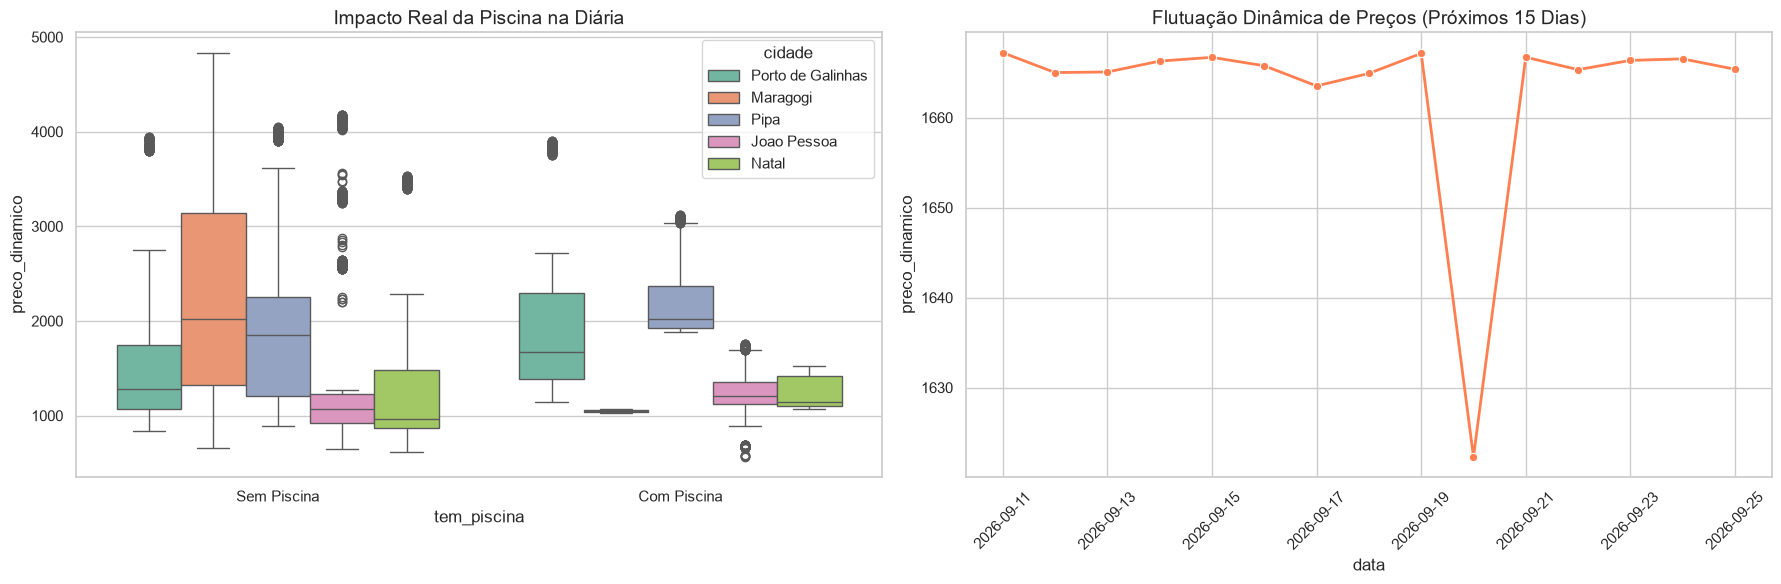

Força da PISCINA no Preço: -0.04
Força da DISTÂNCIA no Preço: -0.10


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot Corrigido: Impacto da Piscina
sns.boxplot(data=df_analise, x='tem_piscina', y='preco_dinamico', hue='cidade', ax=axes[0], palette="Set2")
axes[0].set_title("Impacto Real da Piscina na Diária", fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sem Piscina', 'Com Piscina'])

# Time Series: Curva de Flutuação Climática/Feriados
df_temporal = df_analise.groupby('data')['preco_dinamico'].mean().reset_index()
sns.lineplot(data=df_temporal, x='data', y='preco_dinamico', marker="o", ax=axes[1], color='coral', linewidth=2)
axes[1].set_title("Flutuação Dinâmica de Preços (Próximos 15 Dias)", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Verificação Matemática
print(f"Força da PISCINA no Preço: {df_analise['tem_piscina'].corr(df_analise['preco_dinamico']):.2f}")
print(f"Força da DISTÂNCIA no Preço: {df_analise['distancia_m'].corr(df_analise['preco_dinamico']):.2f}")